In [2]:


import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'
import h5py
import hdf5plugin  # REQUIRED to have the compression plugins available
import numpy as np
from scipy import constants, interpolate
import copy
import glob
import re
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_rows', 1000)
from uvtools.plot import plot_antpos, plot_antclass
from hera_qm import ant_metrics, ant_class, xrfi
from hera_qm import ant_metrics, xrfi
from hera_cal import io, utils, redcal, apply_cal, datacontainer, abscal
from hera_filters import dspec
#from hera_notebook_templates.data import DATA_PATH as HNBT_DATA
from IPython.display import display, HTML
import linsolve
# display(HTML("<style>.container { width:100% !important; }</style>"))
# _ = np.seterr(all='ignore')  # get rid of red warnings
# %config InlineBackend.figure_format = 'retina'



In [3]:
d =150
c=3e8
f=65.0e6
lamd=c/f
res=lamd/d

In [4]:
np.rad2deg(res)

np.float64(1.7629470619409944)

In [5]:
import time
tstart = time.time()
!hostname


jake


In [6]:
# figure out whether to save results
SAVE_RESULTS = os.environ.get("SAVE_RESULTS", "TRUE").upper() == "TRUE"
SAVE_OMNIVIS_FILE = os.environ.get("SAVE_OMNIVIS_FILE", "FALSE").upper() == "TRUE"


# get infile names
SUM_FILE = os.environ.get("SUM_FILE", None)
SUM_FILE = '/net/sinatra/vault-ike/ntsikelelo/Data_H6C/zen.2459861.50015.sum.uvh5' # If sum_file is not defined in the environment variables, define it here.
DIFF_FILE = SUM_FILE.replace('sum', 'diff')

# get outfilenames
AM_FILE = (SUM_FILE.replace('.uvh5', '.ant_metrics.hdf5') if SAVE_RESULTS else None)
ANTCLASS_FILE = (SUM_FILE.replace('.uvh5', '.ant_class.csv') if SAVE_RESULTS else None)
OMNICAL_FILE = (SUM_FILE.replace('.uvh5', '.omni.calfits') if SAVE_RESULTS else None)
OMNIVIS_FILE = (SUM_FILE.replace('.uvh5', '.omni_vis.uvh5') if SAVE_RESULTS else None)

for fname in ['SUM_FILE', 'DIFF_FILE', 'AM_FILE', 'ANTCLASS_FILE', 'OMNICAL_FILE', 'OMNIVIS_FILE', 'SAVE_RESULTS', 'SAVE_OMNIVIS_FILE']:
    print(f"{fname} = '{eval(fname)}'")

SUM_FILE = '/net/sinatra/vault-ike/ntsikelelo/Data_H6C/zen.2459861.50015.sum.uvh5'
DIFF_FILE = '/net/sinatra/vault-ike/ntsikelelo/Data_H6C/zen.2459861.50015.diff.uvh5'
AM_FILE = '/net/sinatra/vault-ike/ntsikelelo/Data_H6C/zen.2459861.50015.sum.ant_metrics.hdf5'
ANTCLASS_FILE = '/net/sinatra/vault-ike/ntsikelelo/Data_H6C/zen.2459861.50015.sum.ant_class.csv'
OMNICAL_FILE = '/net/sinatra/vault-ike/ntsikelelo/Data_H6C/zen.2459861.50015.sum.omni.calfits'
OMNIVIS_FILE = '/net/sinatra/vault-ike/ntsikelelo/Data_H6C/zen.2459861.50015.sum.omni_vis.uvh5'
SAVE_RESULTS = 'True'
SAVE_OMNIVIS_FILE = 'False'


In [7]:
PLOT = os.environ.get("PLOT", "TRUE").upper() == "TRUE"
if PLOT:
    %matplotlib inline

# parse omnical settings
OC_MAX_DIMS = int(os.environ.get("OC_MAX_DIMS", 4))
OC_MIN_DIM_SIZE = int(os.environ.get("OC_MIN_DIM_SIZE", 8))
OC_SKIP_OUTRIGGERS = os.environ.get("OC_SKIP_OUTRIGGERS", "FALSE").upper() == "TRUE"
OC_MIN_BL_LEN = float(os.environ.get("OC_MIN_BL_LEN", 1))
OC_MAX_BL_LEN = float(os.environ.get("OC_MAX_BL_LEN", 1e100))
OC_MAXITER = int(os.environ.get("OC_MAXITER", 50))
OC_MAX_RERUN = int(os.environ.get("OC_MAX_RERUN", 4))
OC_RERUN_MAXITER = int(os.environ.get("OC_MAXITER", 25))
OC_MAX_CHISQ_FLAGGING_DYNAMIC_RANGE = float(os.environ.get("OC_MAX_CHISQ_FLAGGING_DYNAMIC_RANGE", 1))
OC_USE_PRIOR_SOL = os.environ.get("OC_USE_PRIOR_SOL", "FALSE").upper() == "TRUE"
OC_PRIOR_SOL_FLAG_THRESH = float(os.environ.get("OC_PRIOR_SOL_FLAG_THRESH", .95))
OC_USE_GPU = os.environ.get("SAVE_RESULTS", "FALSE").upper() == "TRUE"

# parse RFI settings
RFI_DPSS_HALFWIDTH = float(os.environ.get("RFI_DPSS_HALFWIDTH", 300e-9))
RFI_NSIG = float(os.environ.get("RFI_NSIG", 4))

# parse abscal settings
ABSCAL_MODEL_FILES_GLOB = os.environ.get("ABSCAL_MODEL_FILES_GLOB", None)
ABSCAL_MIN_BL_LEN = float(os.environ.get("ABSCAL_MIN_BL_LEN", 1.0))
ABSCAL_MAX_BL_LEN = float(os.environ.get("ABSCAL_MAX_BL_LEN", 140.0))
CALIBRATE_CROSS_POLS = os.environ.get("CALIBRATE_CROSS_POLS", "FALSE").upper() == "TRUE"

# print settings
for setting in ['PLOT', 'SAVE_RESULTS', 'OC_MAX_DIMS', 'OC_MIN_DIM_SIZE', 'OC_SKIP_OUTRIGGERS', 
                'OC_MIN_BL_LEN', 'OC_MAX_BL_LEN', 'OC_MAXITER', 'OC_MAX_RERUN', 'OC_RERUN_MAXITER', 
                'OC_MAX_CHISQ_FLAGGING_DYNAMIC_RANGE', 'OC_USE_PRIOR_SOL', 'OC_PRIOR_SOL_FLAG_THRESH', 
                'OC_USE_GPU', 'RFI_DPSS_HALFWIDTH', 'RFI_NSIG', 'ABSCAL_MODEL_FILES_GLOB', 
                'ABSCAL_MIN_BL_LEN', 'ABSCAL_MAX_BL_LEN', "CALIBRATE_CROSS_POLS"]:
    print(f'{setting} = {eval(setting)}')

PLOT = True
SAVE_RESULTS = True
OC_MAX_DIMS = 4
OC_MIN_DIM_SIZE = 8
OC_SKIP_OUTRIGGERS = False
OC_MIN_BL_LEN = 1.0
OC_MAX_BL_LEN = 1e+100
OC_MAXITER = 50
OC_MAX_RERUN = 4
OC_RERUN_MAXITER = 25
OC_MAX_CHISQ_FLAGGING_DYNAMIC_RANGE = 1.0
OC_USE_PRIOR_SOL = False
OC_PRIOR_SOL_FLAG_THRESH = 0.95
OC_USE_GPU = False
RFI_DPSS_HALFWIDTH = 3e-07
RFI_NSIG = 4.0
ABSCAL_MODEL_FILES_GLOB = None
ABSCAL_MIN_BL_LEN = 1.0
ABSCAL_MAX_BL_LEN = 140.0
CALIBRATE_CROSS_POLS = False


In [11]:
read_start = time.time()

hd = io.HERAData("/net/sinatra/vault2/ntsikelelo/Data_H6C/zen.2459861.50015.sum.uvh5")
freq_range=hd.freq_array
times=hd.times[0:2]
# data, _, _ = hd.read(frequencies=freq_range)


hd_unfil = io.HERAData("/net/sinatra/vault2/ntsikelelo/Data_H6C/zen.2459861.50015.sum.uvh5")
data_unfil, _, _ = hd_unfil.read(frequencies=freq_range, times=times)
hd_diff = io.HERAData("/net/sinatra/vault2/ntsikelelo/Data_H6C/zen.2459861.50015.diff.uvh5")
diff_data, _, _ = hd_diff.read(frequencies=freq_range,times=times)
print(f'Finished loading data in {(time.time() - read_start) / 60:.2f} minutes.')


Finished loading data in 1.55 minutes.


## Set FLAGGING Parameters

In [12]:
# ant_metrics bounds for low correlation / dead antennas
am_corr_bad = (0, float(os.environ.get("AM_CORR_BAD", 0.3)))
am_corr_suspect = (float(os.environ.get("AM_CORR_BAD", 0.3)), float(os.environ.get("AM_CORR_SUSPECT", 0.5)))

# ant_metrics bounds for cross-polarized antennas
am_xpol_bad = (-1, float(os.environ.get("AM_XPOL_BAD", -0.1)))
am_xpol_suspect = (float(os.environ.get("AM_XPOL_BAD", -0.1)), float(os.environ.get("AM_XPOL_SUSPECT", 0)))

# bounds on solar altitude (in degrees)
good_solar_altitude = (-90, float(os.environ.get("SUSPECT_SOLAR_ALTITUDE", 0)))
suspect_solar_altitude = (float(os.environ.get("SUSPECT_SOLAR_ALTITUDE", 0)), 90)

# bounds on zeros in spectra
good_zeros_per_eo_spectrum = (0, int(os.environ.get("MAX_ZEROS_PER_EO_SPEC_GOOD", 2)))
suspect_zeros_per_eo_spectrum = (0, int(os.environ.get("MAX_ZEROS_PER_EO_SPEC_SUSPECT", 8)))

# bounds on autocorrelation power
auto_power_good = (float(os.environ.get("AUTO_POWER_GOOD_LOW", 5)), float(os.environ.get("AUTO_POWER_GOOD_HIGH", 30)))
auto_power_suspect = (float(os.environ.get("AUTO_POWER_SUSPECT_LOW", 1)), float(os.environ.get("AUTO_POWER_SUSPECT_HIGH", 60)))

# bounds on autocorrelation slope
auto_slope_good = (float(os.environ.get("AUTO_SLOPE_GOOD_LOW", -0.4)), float(os.environ.get("AUTO_SLOPE_GOOD_HIGH", 0.4)))
auto_slope_suspect = (float(os.environ.get("AUTO_SLOPE_SUSPECT_LOW", -0.6)), float(os.environ.get("AUTO_SLOPE_SUSPECT_HIGH", 0.6)))

# bounds on autocorrelation RFI
auto_rfi_good = (0, float(os.environ.get("AUTO_RFI_GOOD", 1.5)))
auto_rfi_suspect = (0, float(os.environ.get("AUTO_RFI_SUSPECT", 2)))

# bounds on autocorrelation shape
auto_shape_good = (0, float(os.environ.get("AUTO_SHAPE_GOOD", 0.1)))
auto_shape_suspect = (0, float(os.environ.get("AUTO_SHAPE_SUSPECT", 0.2)))

# bound on per-xengine non-noiselike power in diff
bad_xengine_zcut = float(os.environ.get("BAD_XENGINE_ZCUT", 10.0))

# bounds on chi^2 per antenna in omnical
oc_cspa_good = (0, float(os.environ.get("OC_CSPA_GOOD", 2)))
oc_cspa_suspect = (0, float(os.environ.get("OC_CSPA_SUSPECT", 3)))

# print bounds
for bound in ['am_corr_bad', 'am_corr_suspect', 'am_xpol_bad', 'am_xpol_suspect', 
              'good_solar_altitude', 'suspect_solar_altitude',
              'good_zeros_per_eo_spectrum', 'suspect_zeros_per_eo_spectrum',
              'auto_power_good', 'auto_power_suspect', 'auto_slope_good', 'auto_slope_suspect',
              'auto_rfi_good', 'auto_rfi_suspect', 'auto_shape_good', 'auto_shape_suspect',
              'bad_xengine_zcut', 'oc_cspa_good', 'oc_cspa_suspect']:
    print(f'{bound} = {eval(bound)}')

am_corr_bad = (0, 0.3)
am_corr_suspect = (0.3, 0.5)
am_xpol_bad = (-1, -0.1)
am_xpol_suspect = (-0.1, 0.0)
good_solar_altitude = (-90, 0.0)
suspect_solar_altitude = (0.0, 90)
good_zeros_per_eo_spectrum = (0, 2)
suspect_zeros_per_eo_spectrum = (0, 8)
auto_power_good = (5.0, 30.0)
auto_power_suspect = (1.0, 60.0)
auto_slope_good = (-0.4, 0.4)
auto_slope_suspect = (-0.6, 0.6)
auto_rfi_good = (0, 1.5)
auto_rfi_suspect = (0, 2.0)
auto_shape_good = (0, 0.1)
auto_shape_suspect = (0, 0.2)
bad_xengine_zcut = 10.0
oc_cspa_good = (0, 2.0)
oc_cspa_suspect = (0, 3.0)


In [13]:
ants = sorted(set([ant for bl in hd.bls for ant in utils.split_bl(bl)]))
auto_bls = [bl for bl in data_unfil if (bl[0] == bl[1]) and (utils.split_pol(bl[2])[0] == utils.split_pol(bl[2])[1])]
antpols = sorted(set([ant[1] for ant in ants]))

In [14]:
# print basic information about the file
print(f'File: {SUM_FILE}')
print(f'JDs: {hd.times} ({np.median(np.diff(hd.times)) * 24 * 3600:.5f} s integrations)')
print(f'LSTS: {hd.lsts * 12 / np.pi } hours')
print(f'Frequencies: {len(hd.freqs)} {np.median(np.diff(hd.freqs)) / 1e6:.5f} MHz channels from {hd.freqs[0] / 1e6:.5f} to {hd.freqs[-1] / 1e6:.5f} MHz')
# print(f'Antennas: {len(hd.data_ants)}')
print(f'Antennas: {len(hd.ants)}')
print(f'Polarizations: {hd.pols}')


File: /net/sinatra/vault-ike/ntsikelelo/Data_H6C/zen.2459861.50015.sum.uvh5
JDs: [2459861.50009578 2459861.50020763] (9.66368 s integrations)
LSTS: [2.60377165 2.60646335] hours
Frequencies: 1536 0.12207 MHz channels from 46.92078 to 234.29871 MHz
Antennas: 350
Polarizations: ['nn', 'ee', 'ne', 'en']


## ANTENNA CLASSIFICATION

In [15]:
am = ant_metrics.AntennaMetrics(SUM_FILE, DIFF_FILE, sum_data=data_unfil, diff_data=diff_data)
am.iterative_antenna_metrics_and_flagging(crossCut=am_xpol_bad[1], deadCut=am_corr_bad[1])
am.all_metrics = {}  # this saves time and disk by getting rid of per-iteration information we never use
if SAVE_RESULTS:
    am.save_antenna_metrics(AM_FILE, overwrite=True)

All-NaN slice encountered


In [16]:


# Turn ant metrics into classifications
totally_dead_ants = [ant for ant, i in am.xants.items() if i == -1]
am_totally_dead = ant_class.AntennaClassification(good=[ant for ant in ants if ant not in totally_dead_ants], bad=totally_dead_ants)
am_corr = ant_class.antenna_bounds_checker(am.final_metrics['corr'], bad=[am_corr_bad], suspect=[am_corr_suspect], good=[(0, 1)])
am_xpol = ant_class.antenna_bounds_checker(am.final_metrics['corrXPol'], bad=[am_xpol_bad], suspect=[am_xpol_suspect], good=[(-1, 1)])
ant_metrics_class = am_totally_dead + am_corr + am_xpol
if np.all([ant_metrics_class[utils.split_bl(bl)[0]] == 'bad' for bl in auto_bls]):
    raise ValueError('All antennas are flagged for ant_metrics.')



In [17]:
min_sun_alt = np.min(utils.get_sun_alt(hd.times))
solar_class = ant_class.antenna_bounds_checker({ant: min_sun_alt for ant in ants}, good=[good_solar_altitude], suspect=[suspect_solar_altitude])


In [18]:
zeros_class = ant_class.even_odd_zeros_checker(data_unfil, diff_data, good=good_zeros_per_eo_spectrum, suspect=suspect_zeros_per_eo_spectrum)
if np.all([zeros_class[utils.split_bl(bl)[0]] == 'bad' for bl in auto_bls]):
    raise ValueError('All antennas are flagged for too many even/odd zeros.')



In [19]:
auto_power_class = ant_class.auto_power_checker(data_unfil, good=auto_power_good, suspect=auto_power_suspect)
#auto_slope_class = ant_class.auto_slope_checker(data, good=auto_slope_good, suspect=auto_slope_suspect, edge_cut=100, filt_size=17)
if np.all([(auto_power_class)[utils.split_bl(bl)[0]] == 'bad' for bl in auto_bls]):
    raise ValueError('All antennas are flagged for bad autocorrelation power/slope.')
overall_class = auto_power_class  + zeros_class + ant_metrics_class + solar_class



## RFI FLAGGING

In [20]:


antenna_flags, array_flags = xrfi.flag_autos(data_unfil, flag_method="channel_diff_flagger", nsig=RFI_NSIG * 5, 
                                             antenna_class=overall_class, flag_broadcast_thresh=.5)
for key in antenna_flags:
    antenna_flags[key] = array_flags
cache = {}
_, array_flags = xrfi.flag_autos(data_unfil, freqs=data_unfil.freqs, flag_method="dpss_flagger",
                                 nsig=RFI_NSIG, antenna_class=overall_class,
                                 filter_centers=[0], filter_half_widths=[RFI_DPSS_HALFWIDTH],
                                 eigenval_cutoff=[1e-9], flags=antenna_flags, mode='dpss_matrix', 
                                 cache=cache, flag_broadcast_thresh=.5)



invalid value encountered in multiply
invalid value encountered in multiply


In [21]:
xengine_diff_class = ant_class.non_noiselike_diff_by_xengine_checker(data_unfil, diff_data, flag_waterfall=array_flags, 
                                                                     antenna_class=overall_class, 
                                                                     xengine_chans=1, bad_xengine_zcut=bad_xengine_zcut)
overall_class += xengine_diff_class
if np.all([overall_class[utils.split_bl(bl)[0]] == 'bad' for bl in auto_bls]):
    raise ValueError('All antennas are flagged after flagging non-noiselike diffs.')

Mean of empty slice
divide by zero encountered in divide


In [22]:
def auto_bl_zscores(data, flag_array, cache={}):
    '''This function computes z-score arrays for each delay-filtered autocorrelation, normalized by the expected noise. 
    Flagged times/channels for the whole array are given 0 weight in filtering and are np.nan in the z-score.'''
    zscores = {}
    for bl in auto_bls:
        wgts = np.array(np.logical_not(flag_array), dtype=np.float64)
        model, _, _ = dspec.fourier_filter(data.freqs, data[bl], wgts, filter_centers=[0], filter_half_widths=[RFI_DPSS_HALFWIDTH], mode='dpss_solve',
                                            suppression_factors=[1e-9], eigenval_cutoff=[1e-9], cache=cache)
        res = data[bl] - model
        int_time = 24 * 3600 * np.median(np.diff(data.times))
        chan_res = np.median(np.diff(data.freqs))
        int_count = int(int_time * chan_res)
        sigma = np.abs(model) / np.sqrt(int_count / 2)
        zscores[bl] = res / sigma    
        zscores[bl][flag_array] = np.nan

    return zscores

In [23]:
def rfi_from_avg_autos(data, auto_bls_to_use, prior_flags=None, nsig=RFI_NSIG):
    '''Average together all baselines in auto_bls_to_use, then find an RFI mask by looking for outliers after DPSS filtering.'''
    
    # Compute int_count for all unflagged autocorrelations averaged together
    int_time = 24 * 3600 * np.median(np.diff(data.times_by_bl[auto_bls[0][0:2]]))
    chan_res = np.median(np.diff(data.freqs))
    int_count = int(int_time * chan_res) * len(auto_bls_to_use)
    avg_auto = {(-1, -1, 'ee'): np.mean([data[bl] for bl in auto_bls_to_use], axis=0)}
    
    # Flag RFI first with channel differences and then with DPSS
    antenna_flags, _ = xrfi.flag_autos(avg_auto, int_count=int_count, nsig=(RFI_NSIG * 5))
    if prior_flags is not None:
        antenna_flags[(-1, -1, 'ee')] = prior_flags
    _, rfi_flags = xrfi.flag_autos(avg_auto, int_count=int_count, flag_method='dpss_flagger',
                                   flags=antenna_flags, freqs=data.freqs, filter_centers=[0],
                                   filter_half_widths=[RFI_DPSS_HALFWIDTH], eigenval_cutoff=[1e-9], nsig=nsig)

    return rfi_flags

In [24]:
# Iteratively develop RFI mask, excess RFI classification, and autocorrelation shape classification
stage = 1
rfi_flags = np.array(array_flags)
prior_end_states = set()
while True:
    print(stage)
    # compute DPSS-filtered z-scores with current array-wide RFI mask
    zscores = auto_bl_zscores(data_unfil, rfi_flags)
    rms = {bl: np.nanmean(zscores[bl]**2)**.5 if np.any(np.isfinite(zscores[bl])) else np.inf for bl in zscores}
    
    # figure out which autos to use for finding new set of flags
    candidate_autos = [bl for bl in auto_bls if overall_class[utils.split_bl(bl)[0]] != 'bad']
    if stage == 1:
        # use best half of the unflagged antennas
        med_rms = np.nanmedian([rms[bl] for bl in candidate_autos])
        autos_to_use = [bl for bl in candidate_autos if rms[bl] <= med_rms]
    elif stage == 2:
        # use all unflagged antennas which are auto RFI good, or the best half, whichever is larger
        med_rms = np.nanmedian([rms[bl] for bl in candidate_autos])
        best_half_autos = [bl for bl in candidate_autos if rms[bl] <= med_rms]
        good_autos = [bl for bl in candidate_autos if (overall_class[utils.split_bl(bl)[0]] != 'bad')
                      and (auto_rfi_class[utils.split_bl(bl)[0]] == 'good')]
        autos_to_use = (best_half_autos if len(best_half_autos) > len(good_autos) else good_autos)
    elif stage == 3:
        # use all unflagged antennas which are auto RFI good or suspect
        autos_to_use = [bl for bl in candidate_autos if (overall_class[utils.split_bl(bl)[0]] != 'bad')]

    # compute new RFI flags
    rfi_flags = rfi_from_avg_autos(data_unfil, autos_to_use)

    # perform auto shape and RFI classification
    overall_class = auto_power_class  + zeros_class + ant_metrics_class + solar_class + xengine_diff_class
    auto_rfi_class = ant_class.antenna_bounds_checker(rms, good=auto_rfi_good, suspect=auto_rfi_suspect, bad=(0, np.inf))
    overall_class += auto_rfi_class
    auto_shape_class = ant_class.auto_shape_checker(data_unfil, good=auto_shape_good, suspect=auto_shape_suspect,
                                                    flag_spectrum=np.sum(rfi_flags, axis=0).astype(bool), 
                                                    antenna_class=overall_class)
    overall_class += auto_shape_class
    
    # check for convergence by seeing whether we've previously gotten to this number of flagged antennas and channels
    if stage == 3:
        if (len(overall_class.bad_ants), np.sum(rfi_flags)) in prior_end_states:
            break
        prior_end_states.add((len(overall_class.bad_ants), np.sum(rfi_flags)))
    else:
        stage += 1

1


invalid value encountered in divide
invalid value encountered in divide
Mean of empty slice


2
3
3
3


In [25]:


auto_class = auto_power_class + auto_rfi_class + auto_shape_class
if np.all([overall_class[utils.split_bl(bl)[0]] == 'bad' for bl in auto_bls]):
    raise ValueError('All antennas are flagged after flagging for bad autos power/slope/rfi/shape.')



In [26]:
def rfi_plot(cls, flags=rfi_flags, data=data_unfil):
    avg_auto = {(-1, -1, 'ee'): np.mean([data[bl] for bl in auto_bls if not cls[utils.split_bl(bl)[0]] == 'bad'], axis=0)}
    plt.figure(figsize=(12, 5), dpi=100)
    plt.semilogy(data.freqs / 1e6, np.where(flags, np.nan, avg_auto[(-1, -1, 'ee')])[0], label = 'Average Good or Suspect Autocorrelation', zorder=100)
    plt.semilogy(data.freqs / 1e6, np.where(False, np.nan, avg_auto[(-1, -1, 'ee')])[0], 'r', lw=.5, label=f'{np.sum(flags[0])} Channels Flagged for RFI')
    plt.legend()
    plt.xlabel('Frequency (MHz)')
    plt.ylabel('Uncalibrated Autocorrelation')
    plt.tight_layout()

Casting complex values to real discards the imaginary part
Casting complex values to real discards the imaginary part


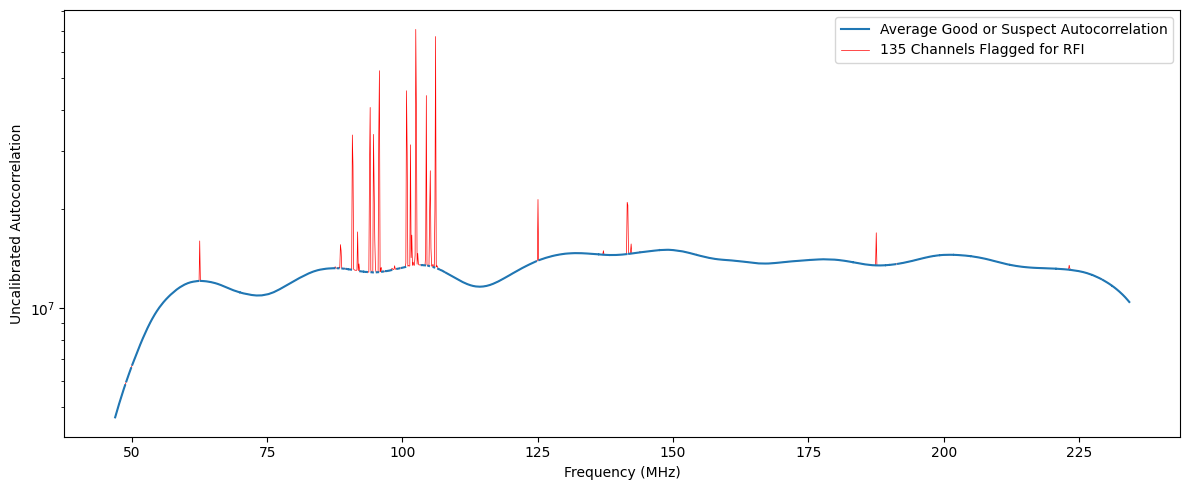

In [27]:
if PLOT: rfi_plot(cls=overall_class, flags=rfi_flags, data=data_unfil)

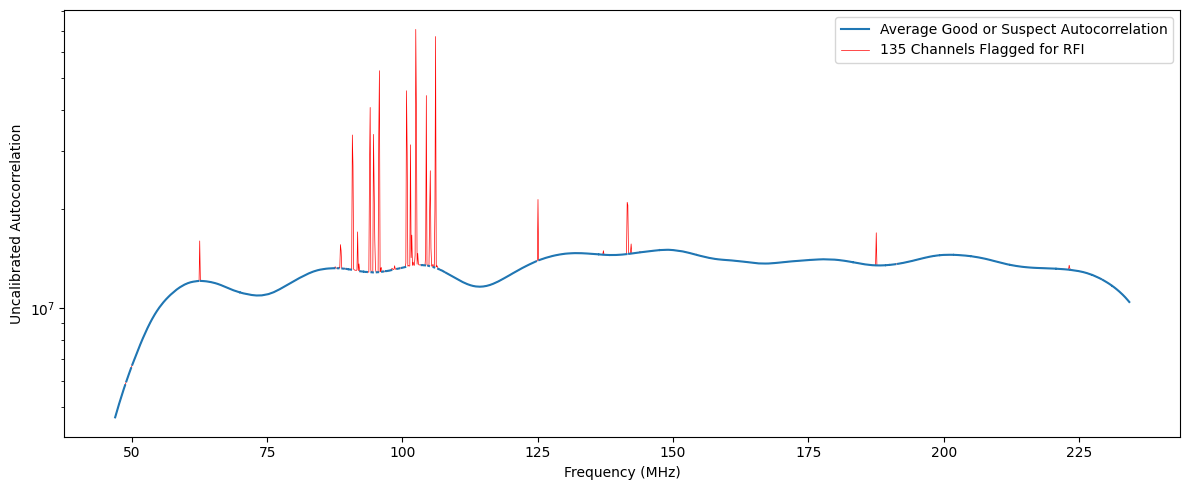

In [28]:
if PLOT: rfi_plot(cls=overall_class, flags=rfi_flags, data=data_unfil)

In [29]:
def autocorr_plot(cls, data=data_unfil):    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100, sharey=True, gridspec_kw={'wspace': 0})
    labels = []
    colors = ['darkgreen', 'goldenrod', 'maroon']
    for ax, pol in zip(axes, antpols):
        for ant in cls.ants:
            if ant[1] == pol:
                color = colors[cls.quality_classes.index(cls[ant])]
                ax.semilogy(np.mean(data[utils.join_bl(ant, ant)], axis=0), color=color, lw=.5)
        ax.set_xlabel('Channel', fontsize=12)
        ax.set_title(f'{utils.join_pol(pol, pol)}-Polarized Autos')

    axes[0].set_ylabel('Raw Autocorrelation', fontsize=12)
    axes[1].legend([matplotlib.lines.Line2D([0], [0], color=color) for color in colors], 
                   [cl.capitalize() for cl in cls.quality_classes], ncol=1, fontsize=12, loc='upper right', framealpha=1)

In [30]:
def array_class_plot(cls, extra_label=""):
    outriggers = [ant for ant in hd.data_ants if ant >= 320]

    if len(outriggers) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=100, gridspec_kw={'width_ratios': [2, 1]})
        plot_antclass(hd.antpos, cls, ax=axes[0], ants=[ant for ant in hd.data_ants if ant < 320], legend=False, title=f'HERA Core{extra_label}')
        plot_antclass(hd.antpos, cls, ax=axes[1], ants=outriggers, radius=50, title='Outriggers')
    else:
        fig, axes = plt.subplots(1, 1, figsize=(9, 6), dpi=100)
        plot_antclass(hd.antpos, cls, ax=axes, ants=[ant for ant in hd.data_ants if ant < 320], legend=False, title=f'HERA Core{extra_label}')



Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


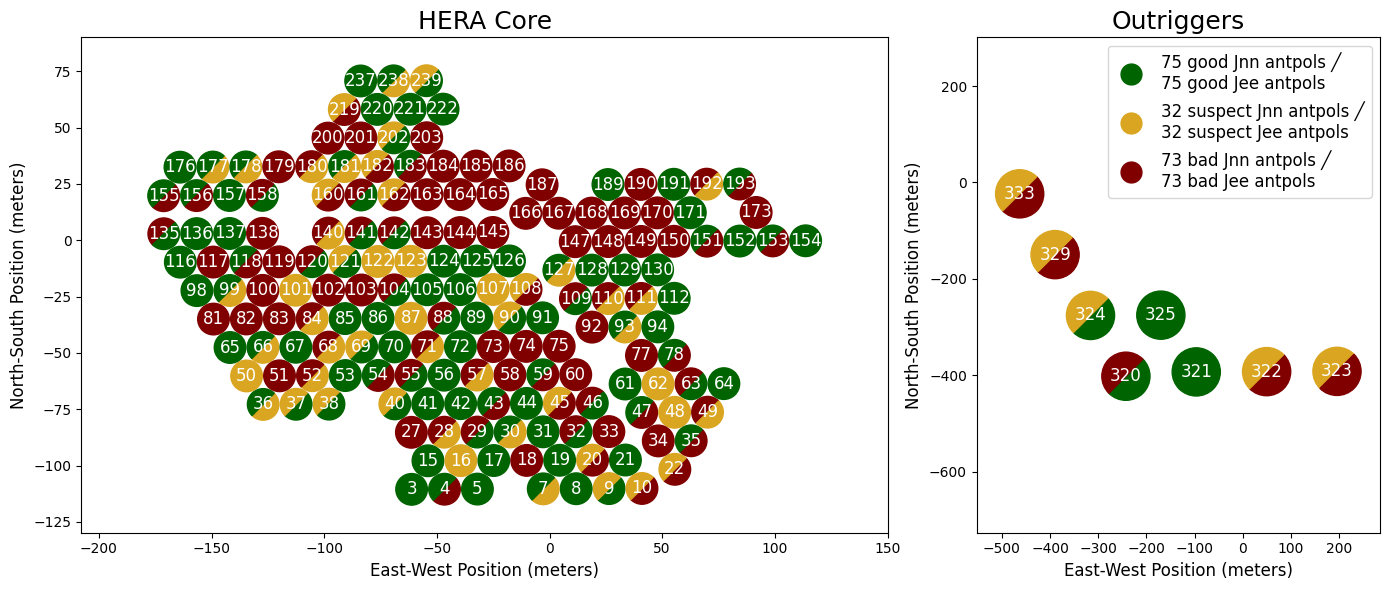

In [31]:
if PLOT: array_class_plot(overall_class)

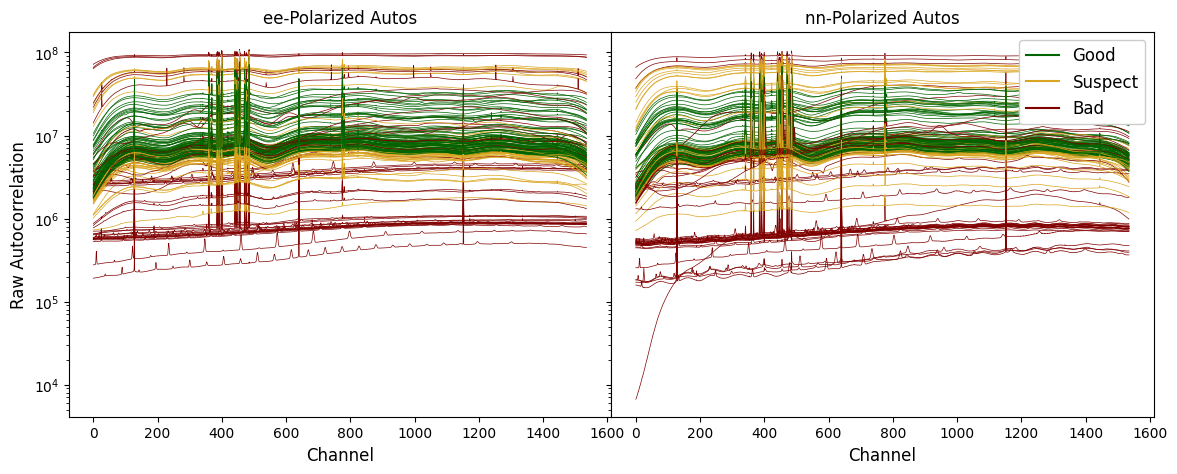

In [32]:


if PLOT: autocorr_plot(cls=auto_class, data=data_unfil)



In [33]:
if PLOT: autocorr_plot(cls=auto_class, data=data)

NameError: name 'data' is not defined

## Perform redundant cal

In [30]:
def classify_off_grid(reds, all_ants):
    '''Returns AntennaClassification of all_ants where good ants are in reds while bad ants are not.'''
    ants_in_reds = set([ant for red in reds for bl in red for ant in utils.split_bl(bl)])
    on_grid = [ant for ant in all_ants if ant in ants_in_reds]
    off_grid = [ant for ant in all_ants if ant not in ants_in_reds]
    return ant_class.AntennaClassification(good=on_grid, bad=off_grid)

In [31]:
def per_pol_filter_reds(reds, pols=['nn', 'ee'], **kwargs):
    '''Performs redcal filtering separately on polarizations (which might have different min_dim_size issues).'''
    return [red for pol in pols for red in redcal.filter_reds(copy.deepcopy(reds), pols=[pol], **kwargs)]

In [32]:
def check_if_whole_pol_flagged(redcal_class, pols=['Jee', 'Jnn']):
    '''Checks if an entire polarization is flagged. If it is, returns True and marks all antennas as bad in redcal_class.'''
    if np.logical_or(*[np.all([redcal_class[ant] == 'bad' for ant in redcal_class.ants if ant[1] == pol]) for pol in pols]):
        print('An entire polarization has been flagged. Stopping redcal.')
        for ant in redcal_class:
            redcal_class[ant] = 'bad'
        return True
    return False

In [33]:


def recheck_chisq(cspa, sol, cutoff, avg_alg, data):
    '''Recompute chisq per ant without apparently bad antennas to see if any antennas get better.'''
    avg_cspa = {ant: avg_alg(np.where(rfi_flags, np.nan, cspa[ant])) for ant in cspa}
    sol2 = redcal.RedSol(sol.reds, gains={ant: sol[ant] for ant in avg_cspa if avg_cspa[ant] <= cutoff}, vis=sol.vis)
    new_chisq_per_ant = {ant: np.array(cspa[ant]) for ant in sol2.gains}
    if len(set([bl[2] for red in per_pol_filter_reds(sol2.reds, ants=sol2.gains.keys(), antpos=hd.data_antpos, **fr_settings) for bl in red])) >= 2:
        redcal.expand_omni_gains(sol2, sol2.reds, data, chisq_per_ant=new_chisq_per_ant)
    for ant in avg_cspa:
        if ant in new_chisq_per_ant:
            if np.any(np.isfinite(new_chisq_per_ant[ant])):
                if not np.all(np.isclose(new_chisq_per_ant[ant], 0)):
                    new_
                    
                    avg_cspa = avg_alg(np.where(rfi_flags, np.nan, cspa[ant]))
                    if new_avg_cspa > 0:
                        avg_cspa[ant] = np.min([avg_cspa[ant], new_avg_cspa])
    return avg_cspa



In [34]:


# figure out and filter reds and classify antennas based on whether or not they are on the main grid
fr_settings = {'max_dims': OC_MAX_DIMS, 'min_dim_size': OC_MIN_DIM_SIZE, 'min_bl_cut': OC_MIN_BL_LEN, 'max_bl_cut': OC_MAX_BL_LEN}
reds = redcal.get_reds(hd.data_antpos, pols=['ee', 'nn'], pol_mode='2pol')
reds = per_pol_filter_reds(reds, ex_ants=overall_class.bad_ants, antpos=hd.data_antpos, **fr_settings)
if OC_SKIP_OUTRIGGERS:
    reds = redcal.filter_reds(reds, ex_ants=[ant for ant in ants if ant[0] >= 320])
redcal_class = classify_off_grid(reds, ants)



## Redundant calibration 

In [35]:
redcal_start = time.time()
rc_settings = {'max_dims': OC_MAX_DIMS, 'oc_conv_crit': 1e-10, 'gain': 0.4, 'run_logcal': False,
               'oc_maxiter': OC_MAXITER, 'check_after': OC_MAXITER, 'use_gpu': OC_USE_GPU}

if check_if_whole_pol_flagged(redcal_class):
    # skip redcal, initialize empty sol and meta 
    sol = redcal.RedSol(reds)
    meta = {'chisq': None, 'chisq_per_ant': None}
else:    
    if OC_USE_PRIOR_SOL:
        # use prior unflagged gains and data to create starting point for next step
        ants_in_reds = set([ant for red in reds for bl in red for ant in utils.split_bl(bl)])
        sol = redcal.RedSol(reds=reds, gains={ant: prior_gains[ant] for ant in not_bad_not_prior_flagged})
        reds_to_update = [[bl for bl in red if (utils.split_bl(bl)[0] in sol.gains) and (utils.split_bl(bl)[1] in sol.gains)] for red in reds]
        reds_to_update = [red for red in reds_to_update if len(red) > 0]
        sol.update_vis_from_data(data, reds_to_update=reds_to_update)
        redcal.expand_omni_gains(sol, reds, data)
        sol.update_vis_from_data(data)
    else:
        # perform first stage of redundant calibration 
        meta, sol = redcal.redundantly_calibrate(data_unfil, reds, **rc_settings)
    
        max_dly = np.max(np.abs(list(meta['fc_meta']['dlys'].values())))  # Needed for RFI delay-slope cal
        median_cspa = recheck_chisq(meta['chisq_per_ant'], sol, oc_cspa_suspect[1] * 5, np.nanmedian, data_unfil)
    
         # remove particularly bad antennas (5x the bound on median, not mean)
        cspa_class = ant_class.antenna_bounds_checker(median_cspa, good=(oc_cspa_good[0], oc_cspa_suspect[1] * 5), bad=[(-np.inf, np.inf)])
        redcal_class += cspa_class
        print(f'Removing {cspa_class.bad_ants} for >5x high median chi^2.')
        for ant in cspa_class.bad_ants:
            print(f'\t{ant}: {median_cspa[ant]:.3f}')
        
    #malloc_trim()

Removing {(28, 'Jee')} for >5x high median chi^2.
	(28, 'Jee'): 26.818


In [36]:


# this enables better memory management on linux
import ctypes
def malloc_trim():
    try:
        ctypes.CDLL('libc.so.6').malloc_trim(0) 
    except OSError:
        pass



In [37]:
# iteratively rerun redundant calibration
redcal_done = False
rc_settings['oc_maxiter'] = rc_settings['check_after'] = OC_RERUN_MAXITER
for i in range(OC_MAX_RERUN + 1):
    # refilter reds and update classification to reflect new off-grid ants, if any
    reds = per_pol_filter_reds(reds, ex_ants=(overall_class + redcal_class).bad_ants, antpos=hd.data_antpos, **fr_settings)
    reds = sorted(reds, key=len, reverse=True)
    redcal_class += classify_off_grid(reds, ants)
    ants_in_reds = set([ant for red in reds for bl in red for ant in utils.split_bl(bl)])
    
    # check to see whether we're done
    if check_if_whole_pol_flagged(redcal_class) or redcal_done or (i == OC_MAX_RERUN):
        break

    # re-run redundant calibration using previous solution, updating bad and suspicious antennas
    meta, sol = redcal.redundantly_calibrate(data_unfil, reds, sol0=sol, **rc_settings)
    malloc_trim()
    
    # recompute chi^2 for bad antennas without bad antennas to make sure they are actually bad
    mean_cspa = recheck_chisq(meta['chisq_per_ant'], sol, oc_cspa_suspect[1], np.nanmean,data_unfil)
    
    # remove bad antennas
    cspa_class = ant_class.antenna_bounds_checker(mean_cspa, good=oc_cspa_good, suspect=oc_cspa_suspect, bad=[(-np.inf, np.inf)])
    for ant in cspa_class.bad_ants:
        if mean_cspa[ant] < np.max(list(mean_cspa.values())) / OC_MAX_CHISQ_FLAGGING_DYNAMIC_RANGE:
            cspa_class[ant] = 'suspect'  # reclassify as suspect if they are much better than the worst antennas
    redcal_class += cspa_class
    print(f'Removing {cspa_class.bad_ants} for high mean unflagged chi^2.')
    for ant in cspa_class.bad_ants:
        print(f'\t{ant}: {mean_cspa[ant]:.3f}')

    if len(cspa_class.bad_ants) == 0:
        redcal_done = True  # no new antennas to flag

print(f'Finished redcal in {(time.time() - redcal_start) / 60:.2f} minutes.')





Removing {(161, 'Jnn')} for high mean unflagged chi^2.
	(161, 'Jnn'): 7.032
Removing {(92, 'Jnn')} for high mean unflagged chi^2.
	(92, 'Jnn'): 6.331
Removing {(77, 'Jee')} for high mean unflagged chi^2.
	(77, 'Jee'): 5.799
Removing {(78, 'Jee')} for high mean unflagged chi^2.
	(78, 'Jee'): 5.152
Finished redcal in 12.71 minutes.


In [38]:
overall_class += redcal_class

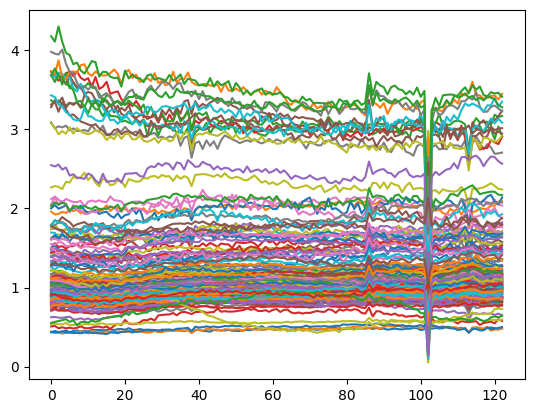

In [39]:
for key in sol.gains:

    plt.plot(np.abs(sol.gains[key][0,:]))

In [40]:
len(overall_class.bad_ants),len(overall_class.suspect_ants)

(145, 148)

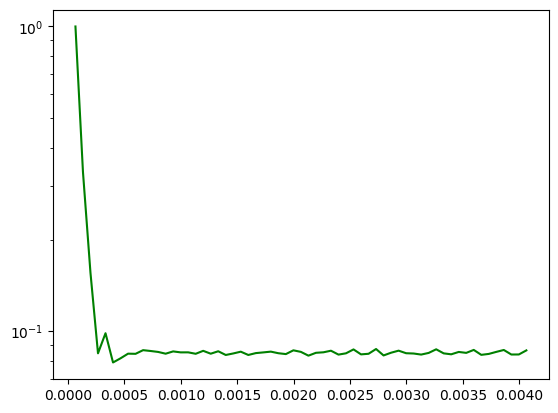

In [41]:
from scipy import signal
tau=np.fft.fftshift(np.fft.fftfreq(len(data_unfil.freqs),np.abs(data_unfil.freqs[1]-data_unfil.freqs[0])))*1e3
index=np.where(tau>0)
tau_pos=tau[index]
window=signal.windows.blackmanharris(len(tau))
g0_delay=[]
for bl in reds[0]:
    cal_data = sol.calibrate_bl(bl, data_unfil[bl]) 
    # plt.semilogy(data.freqs/1e6, np.abs(data_unfil[bl][0]))
    g0_delay.append(cal_data)

g0_mean=np.abs(np.mean(np.array(g0_delay),axis=0))
g0_m=np.fft.fftshift(np.abs(np.fft.fft(window*g0_mean)))[0][index]
vis_2=np.load("no_filte_vis.npy")
plt.semilogy(tau_pos,g0_m/np.max(g0_m),'g')  
# plt.semilogy(tau_pos,vis_2)
# plt.ylim([2e-1,1]) 
# plt.xlim([0,0.001])

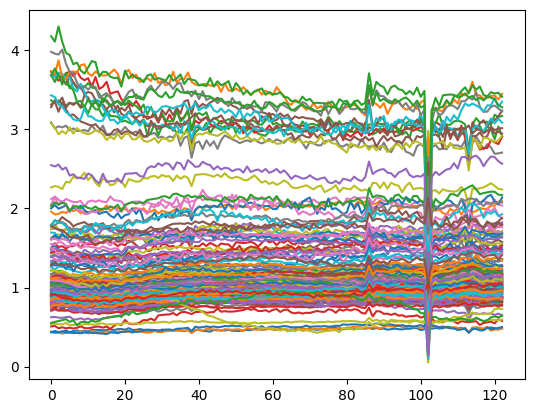

In [42]:
for key in sol.gains:

    plt.plot(np.abs(sol.gains[key][0,:]))

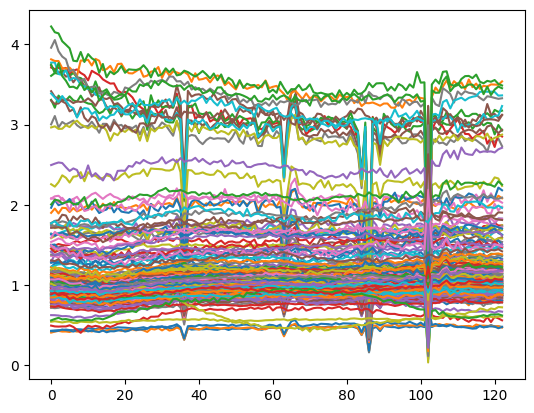

In [43]:
for key in sol.gains:

    plt.plot(np.abs(sol.gains[key][1,:]))

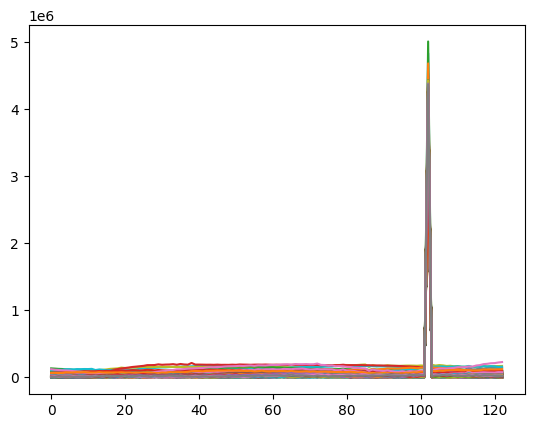

In [44]:
for key in sol.vis:
    plt.plot(np.abs(sol.vis[key][0,:]))

In [45]:
expanded_reds = redcal.get_reds(hd.data_antpos, pols=['ee', 'nn'], pol_mode='2pol')
expanded_reds = per_pol_filter_reds(expanded_reds, ex_ants=(ant_metrics_class + solar_class + zeros_class + auto_class + xengine_diff_class).bad_ants,
                                    max_dims=OC_MAX_DIMS, min_dim_size=OC_MIN_DIM_SIZE)
if OC_SKIP_OUTRIGGERS:
    expanded_reds = redcal.filter_reds(expanded_reds, ex_ants=[ant for ant in ants if ant[0] >= 320])
if len(sol.gains) > 0:
    redcal.expand_omni_vis(sol, expanded_reds, data_unfil, chisq=meta['chisq'], chisq_per_ant=meta['chisq_per_ant'])

In [46]:
# now figure out flags, nsamples etc.
omni_flags = {ant: (~np.isfinite(g)) | (ant in overall_class.bad_ants) for ant, g in sol.gains.items()}
vissol_flags = datacontainer.RedDataContainer({bl: ~np.isfinite(v) for bl, v in sol.vis.items()}, reds=sol.vis.reds)
single_nsamples_array = np.ones((len(times), len(data_unfil.freqs)), dtype=float)
nsamples = datacontainer.DataContainer({bl: single_nsamples_array for bl in data_unfil})
vissol_nsamples = redcal.count_redundant_nsamples(nsamples, [red for red in expanded_reds if red[0] in vissol_flags], 
                                                  good_ants=[ant for ant in overall_class if ant not in overall_class.bad_ants])
for bl in vissol_flags:
    vissol_flags[bl][vissol_nsamples[bl] == 0] = True
sol.make_sol_finite()

In [47]:
def array_chisq_plot(include_outriggers=True):
    if np.all([ant in overall_class.bad_ants for ant in ants]):
        print('All antennas classified as bad. Nothing to plot.')
        return    
    
    def _chisq_subplot(ants, size=250):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)
        for ax, pol in zip(axes, ['ee', 'nn']):
            ants_to_plot = set([ant for ant in meta['chisq_per_ant'] if utils.join_pol(ant[1], ant[1]) == pol and (ant[0] in ants)])
            cspas = np.array([np.nanmean(np.where(rfi_flags, np.nan, meta['chisq_per_ant'][ant])) for ant in ants_to_plot])
            xpos = [hd.antpos[ant[0]][0] for ant in ants_to_plot]
            ypos = [hd.antpos[ant[0]][1] for ant in ants_to_plot]
            scatter = ax.scatter(xpos, ypos, s=size, c=cspas, lw=.25, edgecolors=np.where(np.isfinite(cspas) & (cspas > 0), 'none', 'k'), 
                                 norm=matplotlib.colors.LogNorm(vmin=1, vmax=oc_cspa_suspect[1]))
            for ant in ants_to_plot:
                ax.text(hd.antpos[ant[0]][0], hd.antpos[ant[0]][1], ant[0], va='center', ha='center', fontsize=8,
                        c=('r' if ant in overall_class.bad_ants else 'w'))
            plt.colorbar(scatter, ax=ax, extend='both')
            ax.axis('equal')
            ax.set_xlabel('East-West Position (meters)')
            ax.set_ylabel('North-South Position (meters)')
            ax.set_title(f'{pol}-pol $\\chi^2$ / Antenna (Red is Flagged)')
        plt.tight_layout()    
    
    _chisq_subplot([ant for ant in hd.data_ants if ant < 320])
    outriggers = [ant for ant in hd.data_ants if ant >= 320]    
    if include_outriggers & (len(outriggers) > 0):
        _chisq_subplot([ant for ant in hd.data_ants if ant >= 320], size=400)


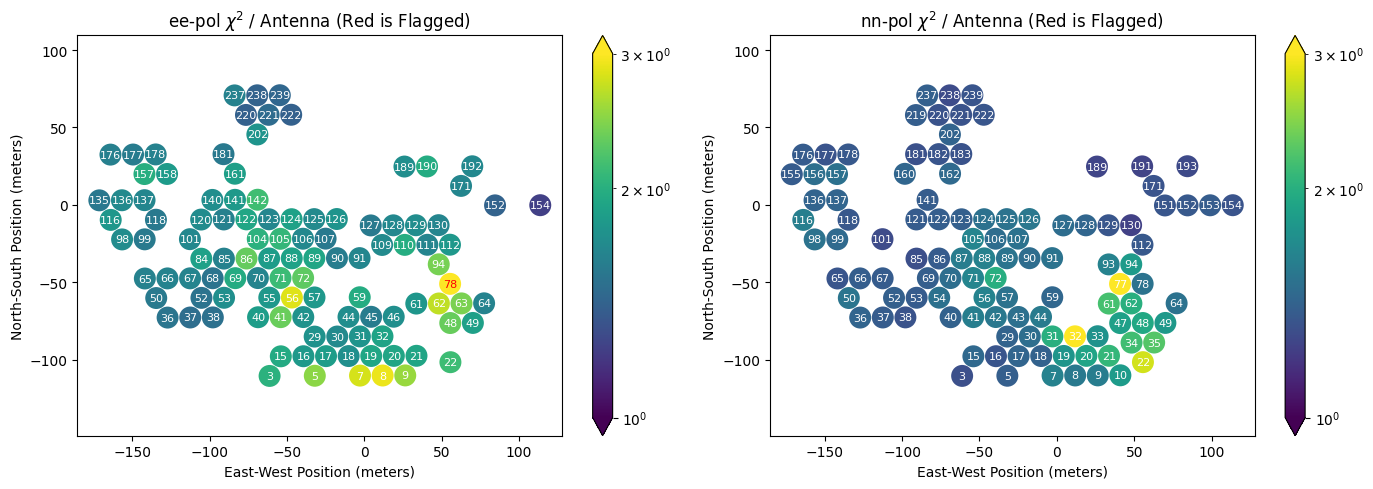

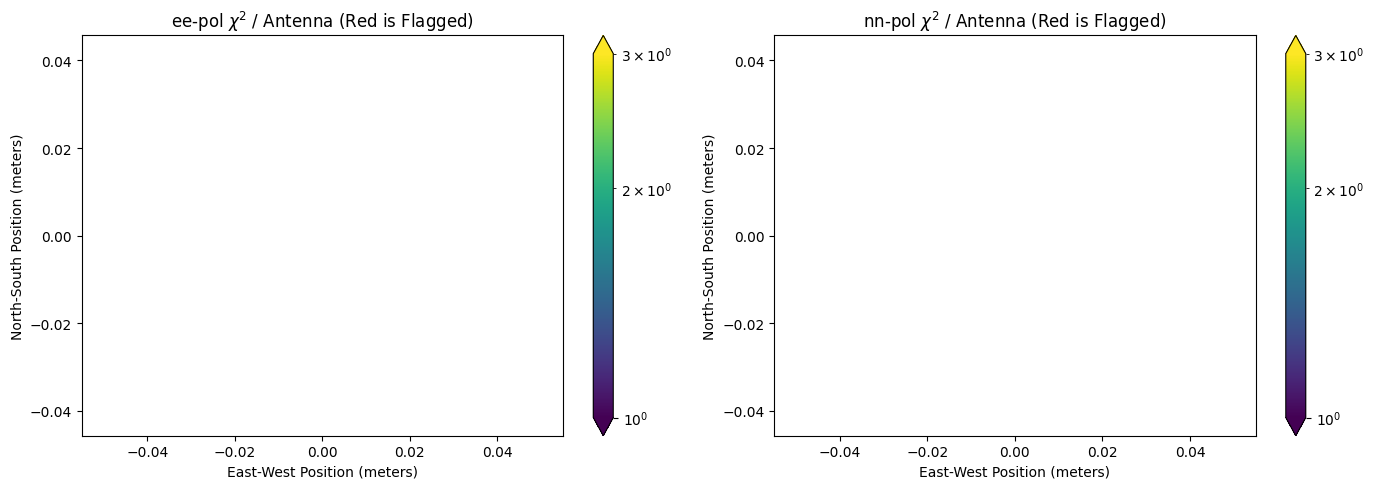

In [48]:
if PLOT: array_chisq_plot(include_outriggers=(not OC_SKIP_OUTRIGGERS))

In [49]:
# if not OC_USE_PRIOR_SOL:
#     # find channels clearly contaminated by RFI
#     not_bad_ants = [ant for ant in overall_class.ants if overall_class[ant] != 'bad']
#     if len(not_bad_ants) > 0:
#         chan_flags = np.mean([xrfi.detrend_medfilt(data[utils.join_bl(ant, ant)], Kf=8, Kt=2) for ant in not_bad_ants], axis=(0, 1)) > 5

#         # hardcoded RFI transmitters and their headings
#         # channel: frequency (Hz), heading (rad), chi^2
#         phs_sol = {359: ( 90744018.5546875, 0.7853981, 23.3),
#                    360: ( 90866088.8671875, 0.7853981, 10.8),
#                    385: ( 93917846.6796875, 0.7853981, 27.3),
#                    386: ( 94039916.9921875, 0.7853981, 18.1),
#                    400: ( 95748901.3671875, 6.0632738, 24.0),
#                    441: (100753784.1796875, 0.7853981, 21.7),
#                    442: (100875854.4921875, 0.7853981, 19.4),
#                    455: (102462768.5546875, 6.0632738, 18.8),
#                    456: (102584838.8671875, 6.0632738,  8.8),
#                    471: (104415893.5546875, 0.7853981, 13.3),
#                    484: (106002807.6171875, 6.0632738, 21.2),
#                    485: (106124877.9296875, 6.0632738,  4.0),
#                   1181: (191085815.4296875, 0.7853981, 26.3),
#                   1182: (191207885.7421875, 0.7853981, 27.0),
#                   1183: (191329956.0546875, 0.7853981, 25.6),
#                   1448: (223678588.8671875, 2.6075219, 25.7),
#                   1449: (223800659.1796875, 2.6075219, 22.6),
#                   1450: (223922729.4921875, 2.6075219, 11.6),
#                   1451: (224044799.8046875, 2.6075219,  5.9),
#                   1452: (224166870.1171875, 2.6075219, 22.6),
#                   1510: (231246948.2421875, 0.1068141, 23.9)}

#         if not np.isclose(data.freqs[0], 46920776.3671875, atol=0.001) or len(data.freqs) != len(freq_range):
#             # We have less frequencies than usual (maybe testing)
#             phs_sol = {np.argmin(np.abs(hd.data - freq)): (freq, heading, chisq) for chan, (freq, heading, chisq) in phs_sol.items() if hd.freqs[0] <= freq <= hd.freqs[-1]}


#         rfi_chans = [chan for chan in phs_sol if chan_flags[chan]]
#         print('Channels used for delay-slope calibration with RFI:', rfi_chans)
#         rfi_angles = np.array([phs_sol[chan][1] for chan in rfi_chans])
#         rfi_headings = np.array([np.cos(rfi_angles), np.sin(rfi_angles), np.zeros_like(rfi_angles)])
#         rfi_chisqs = np.array([phs_sol[chan][2] for chan in rfi_chans])

#         # resolve firstcal degeneracy with delay slopes set by RFI transmitters, update cal
#         RFI_dly_slope_gains = abscal.RFI_delay_slope_cal([red for red in expanded_reds if red[0] in sol.vis], hd.antpos, sol.vis, hd.freqs, rfi_chans, rfi_headings, rfi_wgts=rfi_chisqs**-1,
#                                                          min_tau=-max_dly, max_tau=max_dly, delta_tau=0.1e-9, return_gains=True, gain_ants=sol.gains.keys())
#         sol.gains = {ant: g * RFI_dly_slope_gains[ant] for ant, g in sol.gains.items()}
#         apply_cal.calibrate_in_place(sol.vis, RFI_dly_slope_gains)
#         malloc_trim()


In [62]:
# Try to perform a full abscal of phase

DO_FULL_ABSCAL = True
# figure out appropriate model times to load
matched_model_files=["/net/sinatra/vault-ike/ntsikelelo/Data_H6C/diffuse_model_final.uvh5"]
hdm = io.HERAData(matched_model_files)
sel_pol=hdm.polarization_array
hdm.y_orientation = 'north'
hdm.read(polarizations=sel_pol[0], times =times, frequencies=hd_unfil.freqs)
model_data,_,_=hdm.build_datacontainers()

antenna_diameters are not set or are being overwritten. antenna_diameters are set using values from known telescopes for HERA.
antenna_diameters are not set or are being overwritten. antenna_diameters are set using values from known telescopes for HERA.


In [63]:
# # figure out appropriate model times to load
# matched_model_files=["/net/sinatra/vault-ike/ntsikelelo/Data_H6C/gleam_model_final.uvh5"]
# hdm = io.HERAData(matched_model_files)
# sel_pol=hdm.polarization_array
# hdm.y_orientation = 'north'
# hdm.read(polarizations=sel_pol[0], times =times)
# model_data_compact,_,_=hdm.build_datacontainers()

In [64]:
# # figure out appropriate model times to load
# matched_model_files=["/net/sinatra/vault-ike/ntsikelelo/Data_H6C/diffuse_model_final.uvh5"]
# hdm = io.HERAData(matched_model_files)
# sel_pol=hdm.polarization_array
# hdm.y_orientation = 'north'
# hdm.read(polarizations=sel_pol[0], times =times)
# model_data_diffuse,_,_=hdm.build_datacontainers()

In [65]:
# model_data_full=copy.deepcopy(model_data_compact)

# for bls in model_data_compact:
#     model_data_full[bls]=model_data_compact[bls]+model_data_diffuse[bls]

In [54]:
model_bls=[]
for key in model_data.keys():
    model_bls.append((key[0],key[1],'nn'))

pol='nn'
sel_bls=[]
unflagged_data_bls = [bl for bl in vissol_flags if not np.all(vissol_flags[bl]) and bl[2] == pol]
for key in unflagged_data_bls:
    if key in model_bls:
        sel_bls.append(key)


    

In [66]:
# hd_unfil.update(data=sol.vis)
# hd_unfil.write_uvh5("redundant_cal_data_single_pol.uvh5", clobber=True)   


File exists; clobbering


In [72]:
hd_cal= io.HERAData("redundant_cal_data_single_pol3.uvh5")
hd_cal.read(sel_bls, frequencies=hd_unfil.freqs)
redcal_data,_,_=hd_cal.build_datacontainers()

model_data_modi=copy.deepcopy(redcal_data)
for k in redcal_data.keys():
        model_data_modi[k]=np.array(model_data[(k[0],k[1],'yy')])

In [73]:
gain_cal_pol={}
for k in sol.gains:
    if k[1]=='Jnn':
        gain_cal_pol[k]=sol.gains[k]

rc_flags = {k: np.zeros_like(gain_cal_pol[k], dtype=bool) for k in gain_cal_pol}  
noise_wgts = {k: np.ones_like(redcal_data[k], dtype=float)  for k in redcal_data}
# calibration with lincal gains
calibrated_data = copy.deepcopy(redcal_data)

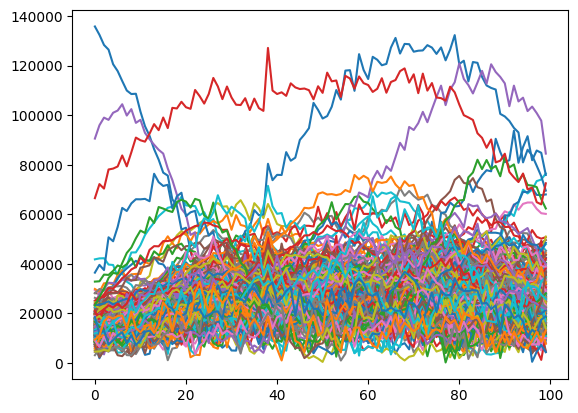

In [74]:
for key in sel_bls:
    #plt.plot(np.abs(data[key][0,:]))

    plt.plot((np.abs(sol.vis[key])[0,:])[:100])

In [75]:
abscal_gains = abscal.post_redcal_abscal(model_data_modi, calibrated_data, noise_wgts, rc_flags, verbose=False)

All-NaN slice encountered
All-NaN slice encountered


In [76]:
calibrated_data_test = copy.deepcopy(redcal_data)
abscal.calibrate_in_place(calibrated_data_test,abscal_gains)

In [77]:
calibrated_data_test = copy.deepcopy(redcal_data)
abscal.calibrate_in_place(calibrated_data_test,abscal_gains)

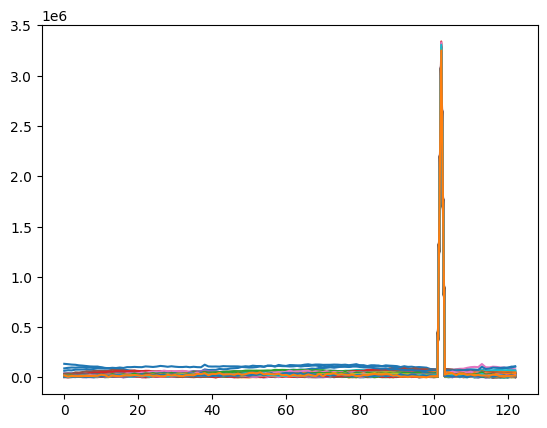

In [78]:
for key in redcal_data:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(calibrated_data[key][0,:]))

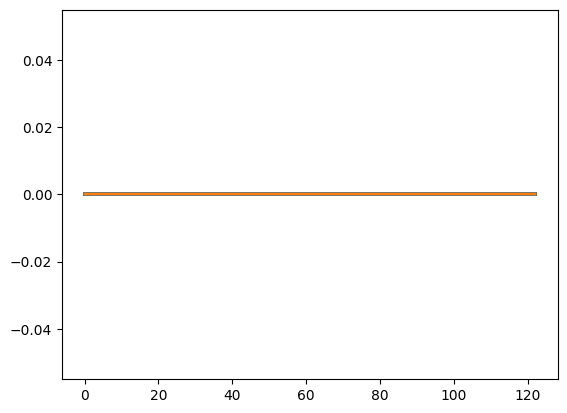

In [79]:
for key in redcal_data:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(model_data_modi[key][0,:]))

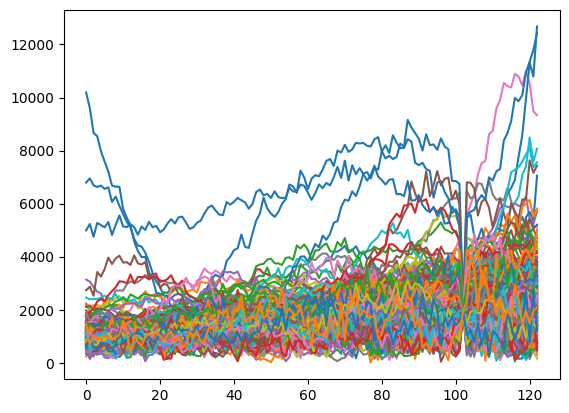

In [203]:
for key in redcal_data:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(calibrated_data[key][0,:]))

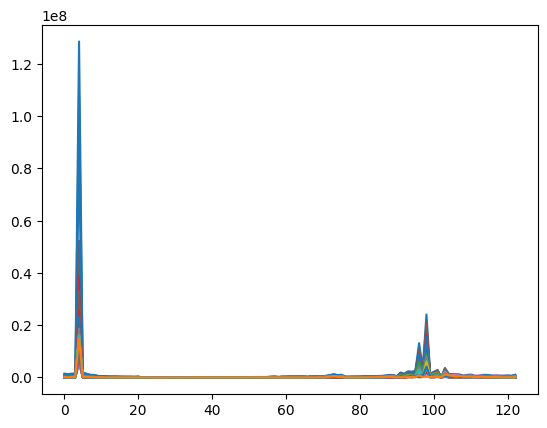

In [204]:
for key in redcal_data:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(calibrated_data_test[key][0,:]))
# plt.ylim([0,600000])    

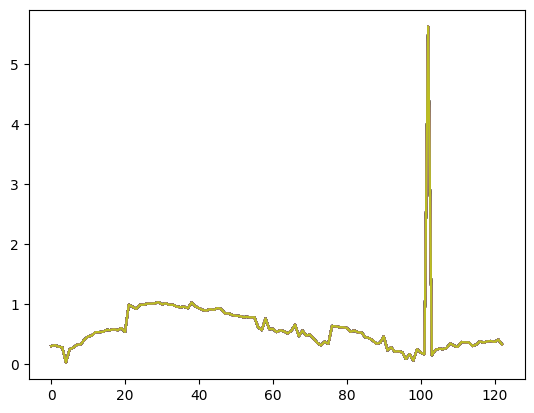

In [205]:
for ant in abscal_gains:

    plt.plot(np.abs(abscal_gains[ant])[0])

In [ ]:
from scipy import signal
tau=np.fft.fftshift(np.fft.fftfreq(len(data.freqs),np.abs(data.freqs[1]-data.freqs[0])))*1e3
index=np.where(tau>0)
tau_pos=tau[index]
window=signal.windows.blackmanharris(len(tau))
g0_delay=[]
for bl in reds[0]:
    cal_data = sol.calibrate_bl(bl, data_unfil[bl]) 
    # plt.semilogy(data.freqs/1e6, np.abs(data_unfil[bl][0]))
    g0=np.fft.fftshift(np.abs(np.fft.fft(window*cal_data)))[0][index]
    g0_delay.append(g0)
    
g0_m=np.mean(np.array(g0_delay), axis=0)
plt.semilogy(tau_pos,g0_m/np.max(g0_m))  
plt.ylim([3e-1,0]) 

In [ ]:
np.array(g0_delay).shape,g0_m.shape,len(tau_pos)

In [ ]:
for bl in reds[0]:
    cal_data = sol.calibrate_bl(bl, data_unfil[bl]) 
    plt.semilogy(data.freqs/1e6, np.abs(data_unfil[bl][0]))
    # plt.semilogy(data.freqs/1e6, np.abs(cal_data)[0])

In [ ]:
def redundant_group_plot(data=data):
    if np.all([ant in overall_class.bad_ants for ant in ants]):
        print('All antennas classified as bad. Nothing to plot.')
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 6), dpi=100, sharex='col', sharey='row', gridspec_kw={'hspace': 0, 'wspace': 0})
    for i, pol in enumerate(['ee', 'nn']):
        reds_here = redcal.get_reds(hd.data_antpos, pols=[pol], pol_mode='1pol')
        red = sorted(redcal.filter_reds(reds_here, ex_ants=overall_class.bad_ants), key=len, reverse=True)[0]
        rc_data = {bl: sol.calibrate_bl(bl, data[bl]) for bl in red}
        for bl in red:
            axes[0, i].plot(data.freqs/1e6, np.angle(rc_data[bl][0]), alpha=.5, lw=.5)
            axes[1, i].semilogy(data.freqs/1e6, np.abs(rc_data[bl][0]), alpha=.5, lw=.5)
        axes[0, i].plot(data.freqs / 1e6, np.angle(sol.vis[red[0]][0]), lw=1, c='k')
        axes[1, i].semilogy(data.freqs / 1e6, np.abs(sol.vis[red[0]][0]), lw=1, c='k', label=f'Baseline Group:\n{red[0]}')
        axes[1, i].set_xlabel('Frequency (MHz)')
        axes[1, i].legend(loc='upper right')
    axes[0, 0].set_ylabel('Visibility Phase (radians)')
    axes[1, 0].set_ylabel('Visibility Amplitude (Jy)')
    plt.tight_layout()


In [ ]:
def abscal_degen_plot():
    if DO_FULL_ABSCAL:
        fig, axes = plt.subplots(3, 1, figsize=(14, 6), dpi=100, sharex=True, gridspec_kw={'hspace': .05})

        for ax, pol in zip(axes[:2], ['ee', 'nn']):
            for kk in range(abscal_meta[pol]['Lambda_sol'].shape[-1]):
                ax.plot(data.freqs[~rfi_flags[0]] * 1e-6, abscal_meta[pol]['Lambda_sol'][0, ~rfi_flags[0], kk], '.', ms=1, label=f"Component {kk}")

            ax.set_ylim(-np.pi-0.5, np.pi+0.5)
            ax.set_xlabel('Frequency (MHz)')
            ax.set_ylabel('Phase Gradient\nVector Component')
            ax.legend(markerscale=20, title=f'{pol}-polarization', loc='lower right')
            ax.grid()
            
        for pol, color in zip(['ee', 'nn'], ['b', 'r']):
            axes[2].plot(data.freqs[~rfi_flags[0]]*1e-6, abscal_meta[pol]['Z_sol'].real[0, ~rfi_flags[0]], '.', ms=1, label=pol, color=color)
        axes[2].set_ylim(-.25, 1.05)
        axes[2].set_ylabel('Re[Z($\\nu$)]')
        axes[2].legend(markerscale=20, loc='lower right')
        axes[2].grid()            
        plt.tight_layout()


In [ ]:
def polarized_gain_phase_plot():
    if CALIBRATE_CROSS_POLS and DO_FULL_ABSCAL:
        plt.figure(figsize=(14, 4), dpi=100)
        for i, time in enumerate(data.times):
            plt.plot(data.freqs / 1e6, np.where(rfi_flags[i], np.nan, delta[i, :]), '.', ms=1.5, label=f'{time:.6f}')
        plt.ylim(-np.pi-0.5, np.pi+0.5)
        plt.xlabel('Frequency (MHz)')
        plt.ylabel('Relative Phase $\Delta \ (\phi_{ee} - \phi_{nn})$')
        plt.grid()
        plt.legend()


In [ ]:
if PLOT: redundant_group_plot(data=data)

In [ ]:
if PLOT: redundant_group_plot(data=data_unfil)

In [ ]:
if PLOT: abscal_degen_plot()

In [ ]:
if PLOT: polarized_gain_phase_plot()

In [ ]:
expand_start = time.time()
expanded_reds = redcal.get_reds(hd.data_antpos, pols=['ee', 'nn'], pol_mode='2pol')
sol.vis.build_red_keys(expanded_reds)
redcal.expand_omni_gains(sol, expanded_reds, data, chisq_per_ant=meta['chisq_per_ant'])
if not np.all([ant in overall_class.bad_ants for ant in ants]):
    redcal.expand_omni_vis(sol, expanded_reds, data)

# Replace near-zeros in gains and infs/nans in gains/sols
for ant in sol.gains:
    zeros_in_gains = np.isclose(sol.gains[ant], 0)
    if ant in omni_flags:
        omni_flags[ant][zeros_in_gains] = True
    sol.gains[ant][zeros_in_gains] = 1.0 + 0.0j
sol.make_sol_finite()
malloc_trim()
print(f'Finished expanding gain solution in {(time.time() - expand_start) / 60:.2f} minutes.')

In [58]:
def array_chisq_plot(include_outriggers=True):
    if np.all([ant in overall_class.bad_ants for ant in ants]):
        print('All antennas classified as bad. Nothing to plot.')
        return    
    
    def _chisq_subplot(ants, size=250):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)
        for ax, pol in zip(axes, ['ee', 'nn']):
            ants_to_plot = set([ant for ant in meta['chisq_per_ant'] if utils.join_pol(ant[1], ant[1]) == pol and (ant[0] in ants)])
            cspas = np.array([np.nanmean(np.where(rfi_flags, np.nan, meta['chisq_per_ant'][ant])) for ant in ants_to_plot])
            xpos = [hd.antpos[ant[0]][0] for ant in ants_to_plot]
            ypos = [hd.antpos[ant[0]][1] for ant in ants_to_plot]
            scatter = ax.scatter(xpos, ypos, s=size, c=cspas, lw=.25, edgecolors=np.where(np.isfinite(cspas) & (cspas > 0), 'none', 'k'), 
                                 norm=matplotlib.colors.LogNorm(vmin=1, vmax=oc_cspa_suspect[1]))
            for ant in ants_to_plot:
                ax.text(hd.antpos[ant[0]][0], hd.antpos[ant[0]][1], ant[0], va='center', ha='center', fontsize=8,
                        c=('r' if ant in overall_class.bad_ants else 'w'))
            plt.colorbar(scatter, ax=ax, extend='both')
            ax.axis('equal')
            ax.set_xlabel('East-West Position (meters)')
            ax.set_ylabel('North-South Position (meters)')
            ax.set_title(f'{pol}-pol $\\chi^2$ / Antenna (Red is Flagged)')
        plt.tight_layout()    
    
    _chisq_subplot([ant for ant in hd.data_ants if ant < 320])
    outriggers = [ant for ant in hd.data_ants if ant >= 320]    
    if include_outriggers & (len(outriggers) > 0):
        _chisq_subplot([ant for ant in hd.data_ants if ant >= 320], size=400)



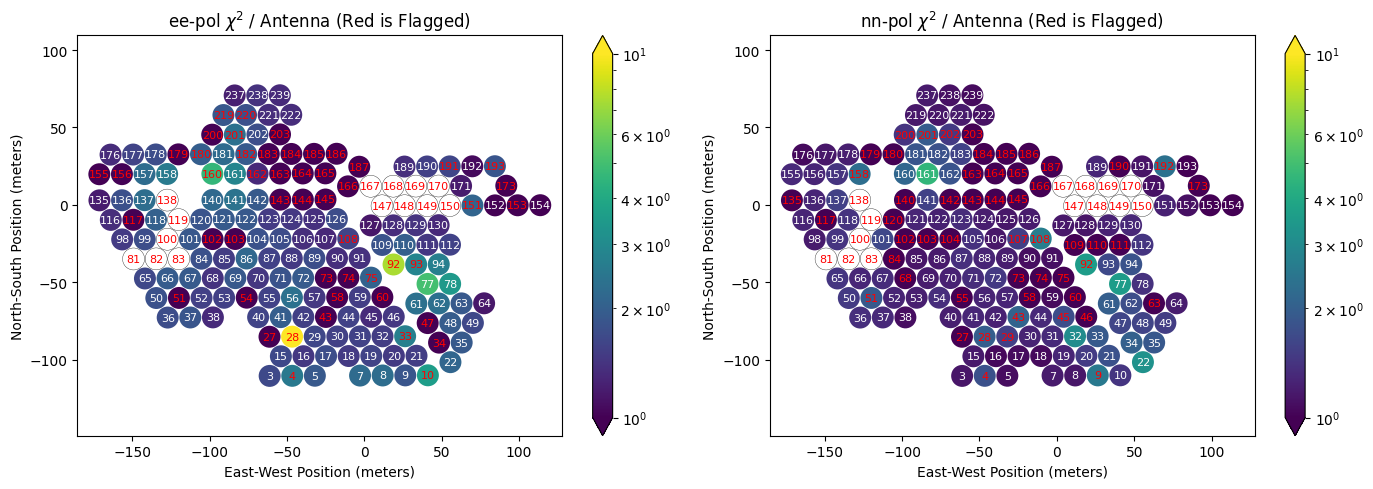

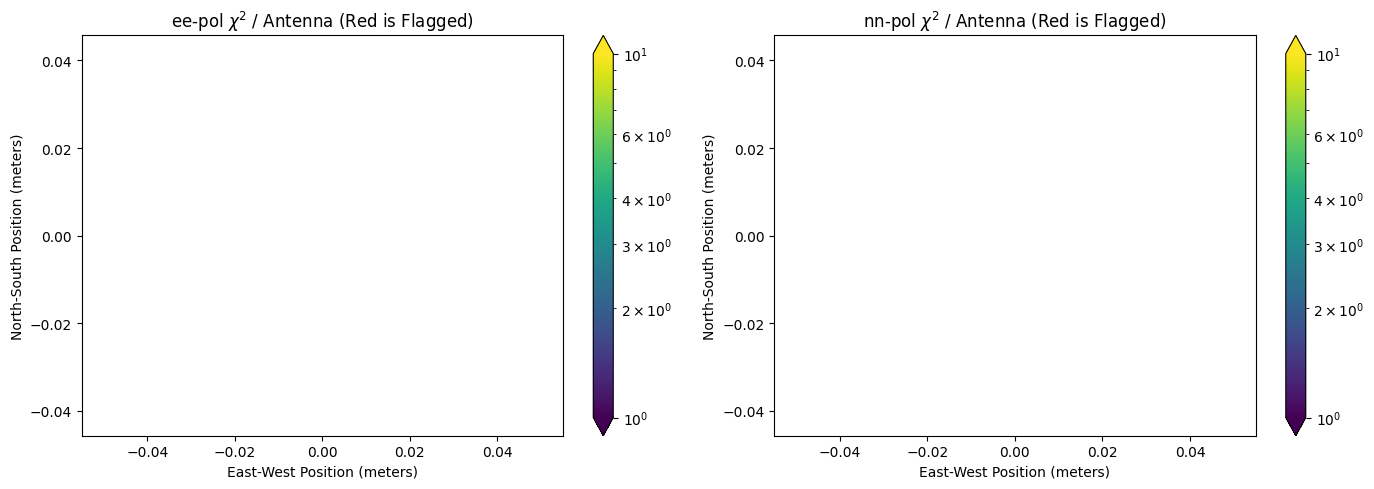

In [59]:
if PLOT: array_chisq_plot(include_outriggers=(not OC_SKIP_OUTRIGGERS))

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


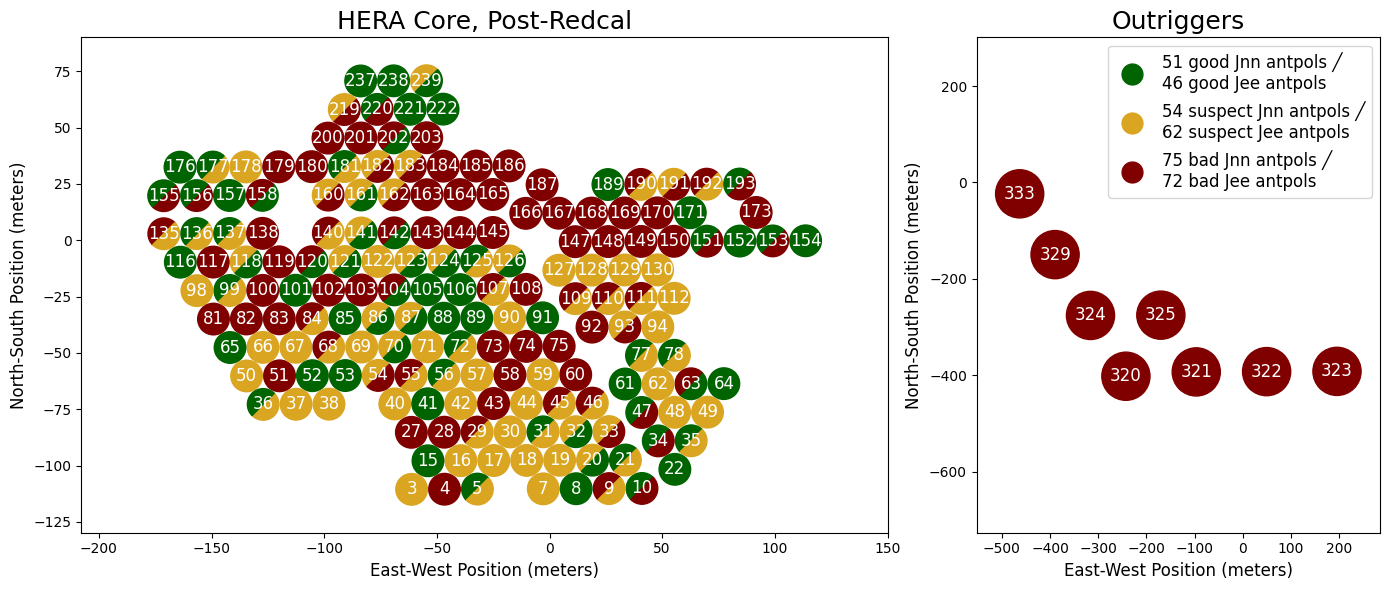

In [60]:
if PLOT: array_class_plot(overall_class, extra_label=", Post-Redcal")